# Hotdog / not hotdog

Project 1, 02516 Introduction to Deep Learning in Computer Vision.

In this notebook we recreated Jian-Yangs infamous hotdog / not hotdog algorithm.

Running it end to end trains eleven models and takes about forty minutes on an M-series
laptop.

## Setup

In [1]:
import glob
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image as Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# to download pretrained models
import certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())

SEED = 42
DATA_PATH = "hotdog_nothotdog"
CLASS_NAMES = ["not hotdog", "hotdog"]


def set_seed(seed=SEED):
    torch.manual_seed(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


set_seed()
device = get_device()
print(f"device: {device}")

device: mps


## Data handling

The dataset in form of a .zip archive was provided us by the professors. 

It consists of two folders with train and test data presplitted with images where hotdog is either present or not. The images come from the different ImageNet categories.

In [2]:
class HotdogNotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path=DATA_PATH):
        self.transform = transform # preprocessing pipeline
        root = os.path.join(data_path, "train" if train else "test")
        # we implicitly sort data so that experiment is reproducible
        classes = sorted((os.path.split(d)[1] for d in glob.glob(root + "/*") if os.path.isdir(d)),
                         key=lambda c: (c == "hotdog", c)) # target class is hotdog
        self.name_to_label = {c: i for i, c in enumerate(classes)}
        self.image_paths = sorted(glob.glob(root + "/*/*.jpg"))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path)
        return self.transform(image), self.label_of(path)

    def label_of(self, path):
        return self.name_to_label[os.path.split(os.path.split(path)[0])[1]]

    def labels(self):
        return np.array([self.label_of(p) for p in self.image_paths])


def load_folders():
    tf = transforms.ToTensor()
    return HotdogNotHotdog(True, tf), HotdogNotHotdog(False, tf)


raw_train, raw_test = load_folders()
y_train, y_test = raw_train.labels(), raw_test.labels()
print(raw_train.name_to_label)

{'nothotdog': 0, 'hotdog': 1}


## EDA

We were giaven a hint, that before diving in model training we have to explore data as it is nonconsistent in terms of sizes and resolution. 
Therefore we formulated three questions for the EDA: how many images per class, what shape they are, and whether the files are what they claim to be.

In [6]:
def describe_classes(labels, name):
    counts = np.bincount(labels, minlength=2)
    print(f"{name} {counts.sum()} images   "
          + "   ".join(f"{CLASS_NAMES[i]} {counts[i]} ({(counts[i] / counts.sum()):.2%})"
                       for i in range(2)))
    return counts


def describe_geometry(paths):
    sizes = []
    for p in paths:
        with Image.open(p) as im:
            sizes.append(im.size)
    sizes = np.array(sizes)
    aspect = sizes[:, 0] / sizes[:, 1]
    print(f"width  min {sizes[:, 0].min()}  median {int(np.median(sizes[:, 0]))}  max {sizes[:, 0].max()}")
    print(f"height min {sizes[:, 1].min()}  median {int(np.median(sizes[:, 1]))}  max {sizes[:, 1].max()}")

    print(f"\naspect median {np.median(aspect):.2f}, "
          f"{(np.abs(np.log(aspect)) > np.log(1.5)).mean():.2%} further than 1.5:1 from square")
    
    return sizes


describe_classes(y_train, "train")
describe_classes(y_test, "test")
print()
train_sizes = describe_geometry(raw_train.image_paths)

train 2047 images   not hotdog 972 (47.48%)   hotdog 1075 (52.52%)
test 1862 images   not hotdog 967 (51.93%)   hotdog 895 (48.07%)

width  min 61  median 500  max 3150
height min 61  median 375  max 2100

aspect median 1.33, 19.88% further than 1.5:1 from square


The two folders lean in opposite directions (trainset has ~48% not hotdog and testset has 48% hotdog), and the images are mostly 4:3 or 3:4 rather
than square, so resizing to a square stretches a fifth of them noticeably.

### Duplicates

By manually going through data, we found complete duplicates. It is important to measure this, because a duplicate split across training and validation means measuring the model's performance on a picture it was trained on.

AI recommended comparing images by a 16x16 average hash. It catches re-encoded copies that a byte-level comparison misses: 207 against 192.

In [7]:
def average_hash(path, n=16):
    with Image.open(path) as im:
        # compressing all images into 16 x 16 pixels
        a = np.asarray(im.convert("L").resize((n, n), Image.BILINEAR), dtype=np.float32)
    return np.packbits(a > a.mean()).tobytes().hex()


def hashes_of(dataset):
    return np.array([average_hash(p) for p in dataset.image_paths])


print(average_hash(raw_train.image_paths[0]))

e1ffc07f907f907f803f883fc03fc41fc20fe10fe007f003f803fc03fe07ffcf


train: 2047 files, 1840 distinct images, 207 redundant copies (10.11%)
test:  35 of 1862 images (1.88%) also sit in the training set

copies whose labels disagree: 0


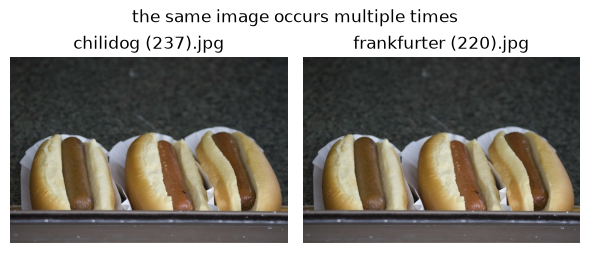

In [8]:
def report_duplicates(train_hashes, test_hashes, labels, paths):
    uniq, first, inverse, counts = np.unique(
        train_hashes, return_index=True, return_inverse=True, return_counts=True)
    dupes = len(train_hashes) - len(uniq)
    print(f"train: {len(train_hashes)} files, {len(uniq)} distinct images, "
          f"{dupes} redundant copies ({dupes / len(train_hashes):.2%})")

    overlap = np.isin(test_hashes, train_hashes)
    print(f"test:  {overlap.sum()} of {len(test_hashes)} images ({overlap.mean():.2%}) "
          f"also sit in the training set")

    conflicts = sum(len(set(labels[inverse == g])) > 1 for g in range(len(uniq)))
    print(f"\ncopies whose labels disagree: {conflicts}")

    pair = np.flatnonzero(inverse == np.flatnonzero(counts > 1)[0])[:2]
    fig, axes = plt.subplots(1, 2, figsize=(6, 2.6))
    for ax, idx in zip(axes, pair):
        ax.imshow(Image.open(paths[idx]))
        ax.set_title(os.path.basename(paths[idx]))
        ax.axis("off")
    fig.suptitle("the same image occurs multiple times")
    fig.tight_layout()
    plt.show()

    return np.sort(first)

train_hashes, test_hashes = hashes_of(raw_train), hashes_of(raw_test)
UNIQUE_IDX = report_duplicates(train_hashes, test_hashes, y_train,
                               np.array(raw_train.image_paths))

A 1/10 of the training folder is redundant, and 35 test images are also present in train set.
Labels never disagree between copies.

The training-side duplication we can fix by keeping one copy of each image before
splitting. The test overlap we cannot, since the test set is fixed by the assignment, so
the final section reports accuracy on the full test set and on the subset the model has
provably never seen!

### The split

A plain random_split has two problems at once here.

In [9]:
def split_report(train_idx, val_idx, hashes, labels, title):
    leaked = np.isin(hashes[val_idx], hashes[train_idx]).sum()
    print(title + "\n")

    for idx, name in [(train_idx, "train"), (val_idx, "val")]:
        counts = np.bincount(labels[idx], minlength=2)
        print(f"{name} {counts.sum()} images | hotdog {counts[1] / counts.sum():.2%}")
        
    print(f"test {len(y_test)} images | hotdog {np.bincount(y_test)[1] / len(y_test):.2%}")
    print(f"\nvalidation images with a copy in train: {leaked} ({leaked / len(val_idx):.2%})")


n_train = int(0.8 * len(raw_train))
naive = torch.utils.data.random_split(
    raw_train, [n_train, len(raw_train) - n_train],
    generator=torch.Generator().manual_seed(SEED))
split_report(np.array(naive[0].indices), np.array(naive[1].indices),
             train_hashes, y_train, "plain random_split")

plain random_split

train 1637 images | hotdog 51.86%
val 410 images | hotdog 55.12%
test 1862 images | hotdog 48.07%

validation images with a copy in train: 74 (18.05%)


The class ratio drifts seven points away from the test set, and almost a 1/5 of the
validation images have a twin in the train set.

Deduplicating first removes the second problem, and drawing the validation fraction inside each class removes the first.

In [10]:
def stratified_split(indices, labels, val_fraction=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    train_idx, val_idx = [], []
    for cls in np.unique(labels[indices]):
        pool = rng.permutation(indices[labels[indices] == cls])
        cut = int(round(len(pool) * (1 - val_fraction)))
        train_idx.append(pool[:cut])
        val_idx.append(pool[cut:])
        
    return np.sort(np.concatenate(train_idx)), np.sort(np.concatenate(val_idx))


TRAIN_IDX, VAL_IDX = stratified_split(UNIQUE_IDX, y_train)
TEST_UNSEEN = ~np.isin(test_hashes, train_hashes[TRAIN_IDX])

split_report(TRAIN_IDX, VAL_IDX, train_hashes, y_train, "deduplicated + stratified")
print(f"test images never used in training: {TEST_UNSEEN.sum()} of {len(TEST_UNSEEN)}")

deduplicated + stratified

train 1472 images | hotdog 47.15%
val 368 images | hotdog 47.28%
test 1862 images | hotdog 48.07%

validation images with a copy in train: 0 (0.00%)
test images never used in training: 1831 of 1862


Deduplication also pulls the training class ratio from 52.5% down to 47%, much closer to
the test folder. The copies were concentrated in the hotdog class, which is what you would
expect when three of the source categories are all kinds of hotdog.

## Pipeline

Here we build pipline building blocks for preprocessing, loaders, training and evaluation.

In [11]:
def build_transforms(size=128, augment=False, normalize=None, keep_aspect=False):
    """Function for using different scenarios for preprocessing raw data"""

    def base(train):
        steps = []
        if keep_aspect:
            steps += [transforms.Resize(size), transforms.CenterCrop(size)]
        else:
            steps += [transforms.Resize((size, size))]
        if train and augment:
            steps += [transforms.RandomHorizontalFlip(),
                      transforms.RandomRotation(15),
                      transforms.ColorJitter(brightness=0.2, contrast=0.2)]
        steps += [transforms.ToTensor()]
        if normalize is not None:
            steps += [transforms.Normalize(*normalize)]
        return transforms.Compose(steps)

    return base(True), base(False)


def make_loaders(train_transform, eval_transform, batch_size=64, num_workers=0):
    """Function for using different loaders"""

    train_base = HotdogNotHotdog(True, train_transform)
    eval_base = HotdogNotHotdog(True, eval_transform)
    kw = dict(num_workers=num_workers)
    
    return (
        # train: preprocessed, shuffled
        DataLoader(Subset(train_base, TRAIN_IDX), batch_size=batch_size, shuffle=True, **kw),
        # val: source images, fixed order
        DataLoader(Subset(eval_base, VAL_IDX), batch_size=batch_size, shuffle=False, **kw),
        # test: untouched until the very end
        DataLoader(HotdogNotHotdog(False, eval_transform), batch_size=batch_size,
                   shuffle=False, **kw),
    )


def dataset_statistics(size=128):
    """Function for exploring the task of input data normalization 
        - as recommended by the course
    """

    _, eval_tf = build_transforms(size=size)
    loader = DataLoader(Subset(HotdogNotHotdog(True, eval_tf), TRAIN_IDX), batch_size=64)
    total = torch.zeros(3)
    total_sq = torch.zeros(3)
    n = 0
    for images, _ in loader:
        total += images.sum(dim=(0, 2, 3))
        total_sq += (images ** 2).sum(dim=(0, 2, 3))
        n += images.shape[0] * images.shape[2] * images.shape[3]
    mean = total / n
    std = (total_sq / n - mean ** 2).sqrt()

    return mean.tolist(), std.tolist()


DATASET_STATS = dataset_statistics()
print("train set channel mean/std:",
      [round(v, 3) for v in DATASET_STATS[0]], [round(v, 3) for v in DATASET_STATS[1]])

train set channel mean/std: [0.518, 0.439, 0.359] [0.272, 0.264, 0.274]


Cell above shows that input images have mean around 0.4, which requires normalization, so that first layer doesn't waste it's capacity on that 

In [12]:
RESULTS = {}


def train_epoch(model, loader, loss_fn, optimizer):
    """Function for training the model"""
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    
    # iterate over all batches
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(images) # forward pass
        loss = loss_fn(outputs, targets)
        loss.backward() # backprop
        optimizer.step()
        # we will take average over all batches
        loss_sum += loss.item() * targets.size(0)
        correct += (outputs.argmax(1) == targets).sum().item()
        total += targets.size(0)
    
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn=None):
    """Function for evaluating the model"""

    loss_fn = loss_fn or nn.CrossEntropyLoss()
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0

    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)
        # we will take average over all batches
        loss_sum += loss_fn(outputs, targets).item() * targets.size(0)
        correct += (outputs.argmax(1) == targets).sum().item()
        total += targets.size(0)

    return loss_sum / total, correct / total


def experiment(name, build_model, *, size=128, augment=False, normalize=None,
               keep_aspect=False, batch_size=64, epochs=10, optimizer_fn=None,
               loss_fn=None, scheduler_fn=None, note="", verbose=True):

    """Function for running the experiment"""
    
    train_tf, eval_tf = build_transforms(size=size, augment=augment,
                                         normalize=normalize, keep_aspect=keep_aspect)
    train_loader, val_loader, _ = make_loaders(train_tf, eval_tf, batch_size=batch_size)

    # same starting weights for every experiment, so a difference between two runs
    # is the change we made and not a different random draw
    set_seed()
    model = build_model().to(device)
    loss_fn = loss_fn or nn.CrossEntropyLoss()
    optimizer = (optimizer_fn or (lambda p: torch.optim.Adam(p, lr=1e-3)))(model.parameters())
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None # adjusting learning rate on the go

    history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc"]}
    best = {"val_acc": -1.0, "epoch": -1, "state": None}
    started = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, loss_fn, optimizer)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn)
        if scheduler:
            scheduler.step()
        for key, value in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
            history[key].append(value)
        if va_acc > best["val_acc"]:
            best = {"val_acc": va_acc, "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
        if verbose:
            print(f"  epoch {epoch:2d}/{epochs}  train {tr_loss:.4f}/{tr_acc:.4f}   "
                  f"val {va_loss:.4f}/{va_acc:.4f}")

    model.load_state_dict(best["state"]) # roll back to the best epoch
    RESULTS[name] = {"name": name, "note": note, "val_acc": best["val_acc"],
                     "best_epoch": best["epoch"],
                     "val_loss": history["val_loss"][best["epoch"] - 1],
                     "train_acc_last": history["train_acc"][-1],
                     "params": sum(p.numel() for p in model.parameters()),
                     "epochs": epochs, "seconds": time.time() - started}
    if verbose:
        print(f"{name}: best val acc {best['val_acc']:.4f} (epoch {best['epoch']}), "
              f"{RESULTS[name]['seconds']:.0f}s")

    return {"model": model.eval() , "history": history}


def results_table(names=None):
    """Function for printing the results table"""

    names = names or list(RESULTS)
    rows = [RESULTS[n] for n in names]
    w = max(len(r["name"]) for r in rows)
    note_w = max([len(r.get("note", "")) for r in rows] + [4])

    print(f"{'step'.ljust(w)}  {'val acc':>8}  {'val loss':>8}  {'train acc':>9}  "
          f"{'epoch':>5}  {'params':>11}  {'what changed'.ljust(note_w)}")
    
    for r in rows:
        print(f"{r['name'].ljust(w)}  {r['val_acc']:8.4f}  {r['val_loss']:8.4f}  "
              f"{r['train_acc_last']:9.4f}  {r['best_epoch']:5d}  {r['params']:11,}  "
              f"{r.get('note', '')}")


def plot_histories(blobs, labels, title=""):
    """Function for plotting the histories"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
    
    for blob, label in zip(blobs, labels):
        h = blob["history"]
        ep = range(1, len(h["train_loss"]) + 1)
        line, = ax1.plot(ep, h["val_loss"], label=label)
        ax1.plot(ep, h["train_loss"], color=line.get_color(), ls="--", alpha=0.45)
        ax2.plot(ep, h["val_acc"], color=line.get_color(), label=label)
        ax2.plot(ep, h["train_acc"], color=line.get_color(), ls="--", alpha=0.45)
    ax1.set_xlabel("epoch"), ax1.set_ylabel("loss"), ax1.legend(fontsize=8), ax1.grid(alpha=0.3)
    ax2.set_xlabel("epoch"), ax2.set_ylabel("accuracy"), ax2.legend(fontsize=8), ax2.grid(alpha=0.3)
    fig.suptitle(f"{title}   (dashed: train, solid: val)", fontsize=10)
    fig.tight_layout(), plt.show()

## Step 1: where we start

In our first experiment we used network from our homework exercises: three convolutions with pooling, then two fully connected layers. 
Images are resized to 128x128 and fed in as raw tensors with no preprocessing.

  epoch  1/10  train 0.6244/0.6393   val 0.5469/0.7255
  epoch  2/10  train 0.5354/0.7405   val 0.4996/0.7500
  epoch  3/10  train 0.5062/0.7527   val 0.4778/0.7853
  epoch  4/10  train 0.4808/0.7649   val 0.4824/0.7772
  epoch  5/10  train 0.4681/0.7697   val 0.4683/0.7690
  epoch  6/10  train 0.4367/0.8030   val 0.4798/0.7826
  epoch  7/10  train 0.4335/0.7969   val 0.4570/0.7962
  epoch  8/10  train 0.3924/0.8240   val 0.4408/0.8016
  epoch  9/10  train 0.3412/0.8505   val 0.4595/0.8016
  epoch 10/10  train 0.3130/0.8668   val 0.4864/0.7908
01_simple_cnn: best val acc 0.8016 (epoch 8), 74s


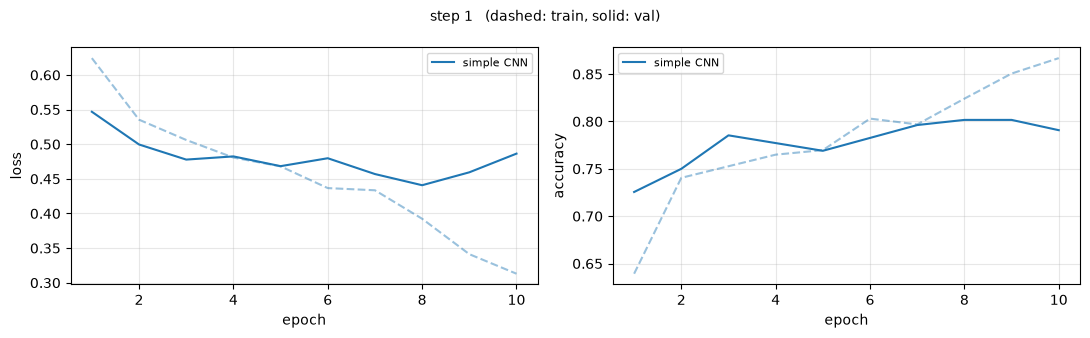

In [13]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (128 // (2*2*2)) ** 2, 128), 
            nn.ReLU(),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


step1 = experiment("01_simple_cnn", SimpleCNN, epochs=10, note="starting point")
plot_histories([step1], ["simple CNN"], "step 1")

Validation peaks around epoch 6 and then drifts while training accuracy keeps climbing past 88%. 
This indicates us taht model is fitting to the particular pictures. 
The next moves are about capacity and regularisation rather than more epochs.

## Step 2: a head that is not mostly one linear layer

Two changes: a fourth convolution layer and global average pooling instead of flattening, which replaces two million parameters with none. 
The classifier then works on 128 numbers rather than thousands and is able to spot hotdog in any position on the image.

  epoch  1/20  train 0.6842/0.5639   val 0.6653/0.5707
  epoch  2/20  train 0.6560/0.6067   val 0.6739/0.5598
  epoch  3/20  train 0.6396/0.6386   val 0.6438/0.6332
  epoch  4/20  train 0.6308/0.6467   val 0.6294/0.6413
  epoch  5/20  train 0.6223/0.6576   val 0.5989/0.6793
  epoch  6/20  train 0.5919/0.6943   val 0.5747/0.7147
  epoch  7/20  train 0.5771/0.7045   val 0.5758/0.6957
  epoch  8/20  train 0.5621/0.7167   val 0.5480/0.7228
  epoch  9/20  train 0.5366/0.7385   val 0.5301/0.7283
  epoch 10/20  train 0.5539/0.7310   val 0.5379/0.7201
  epoch 11/20  train 0.5477/0.7242   val 0.5161/0.7364
  epoch 12/20  train 0.5016/0.7677   val 0.5156/0.7554
  epoch 13/20  train 0.4760/0.7860   val 0.4947/0.7663
  epoch 14/20  train 0.4780/0.7894   val 0.4710/0.7745
  epoch 15/20  train 0.4635/0.7955   val 0.4665/0.7826
  epoch 16/20  train 0.4593/0.7935   val 0.5150/0.7717
  epoch 17/20  train 0.4567/0.7962   val 0.4741/0.7745
  epoch 18/20  train 0.4458/0.8030   val 0.5093/0.7880
  epoch 19

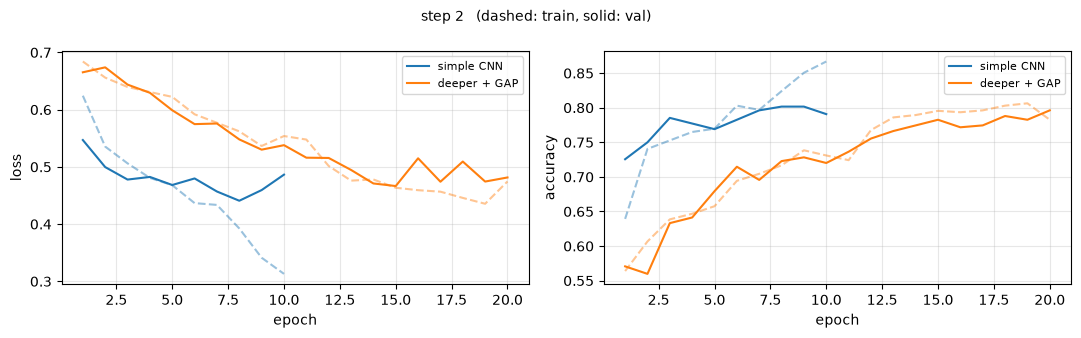

step            val acc  val loss  train acc  epoch       params  what changed            
01_simple_cnn    0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap    0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool


In [14]:
class DeeperCNN(nn.Module):
    def __init__(self):
        
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1) # global average pooling
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


step2 = experiment("02_deeper_gap", DeeperCNN, epochs=20, note="deeper + global avg pool")
plot_histories([step1, step2], ["simple CNN", "deeper + GAP"], "step 2")

results_table()

## Step 3: normalising the input

Raw pixels arrive with a channel mean near 0.5, so the first layer wastes capacity undoing that offset. 
Subtracting the channel mean and dividing by the standard deviation puts the input around zero, which is what the initialisation schemes assume. 
Normalization is done strictly on the statistics that come from the train set.

  epoch  1/20  train 0.6740/0.5774   val 0.6470/0.6196
  epoch  2/20  train 0.6350/0.6562   val 0.6234/0.6658
  epoch  3/20  train 0.6122/0.6814   val 0.6071/0.6766
  epoch  4/20  train 0.6027/0.6970   val 0.5908/0.7011
  epoch  5/20  train 0.5748/0.7154   val 0.5456/0.6957
  epoch  6/20  train 0.5538/0.7371   val 0.5495/0.7120
  epoch  7/20  train 0.5484/0.7364   val 0.5167/0.7283
  epoch  8/20  train 0.5167/0.7568   val 0.4943/0.7527
  epoch  9/20  train 0.4869/0.7649   val 0.4916/0.7663
  epoch 10/20  train 0.4837/0.7677   val 0.4807/0.7636
  epoch 11/20  train 0.4954/0.7554   val 0.5071/0.7799
  epoch 12/20  train 0.4518/0.7921   val 0.4633/0.7772
  epoch 13/20  train 0.4390/0.8043   val 0.4563/0.7880
  epoch 14/20  train 0.4375/0.8159   val 0.4655/0.7826
  epoch 15/20  train 0.4279/0.8098   val 0.4623/0.8071
  epoch 16/20  train 0.4170/0.8227   val 0.5060/0.7772
  epoch 17/20  train 0.4143/0.8166   val 0.4410/0.8098
  epoch 18/20  train 0.4088/0.8247   val 0.4781/0.8098
  epoch 19

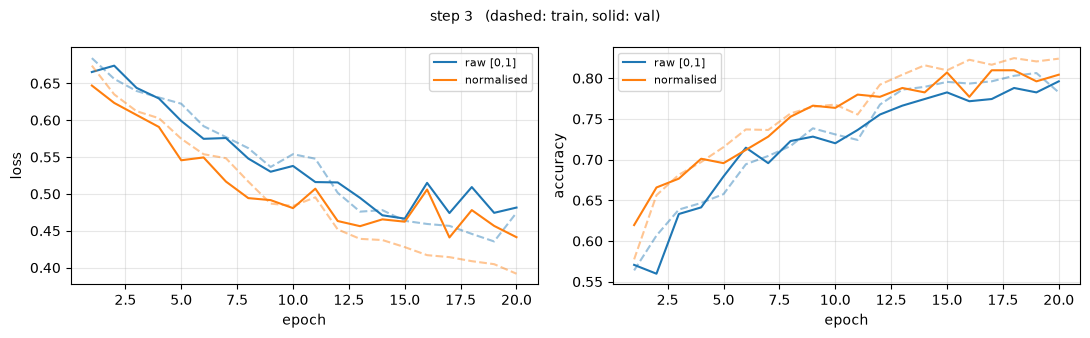

step            val acc  val loss  train acc  epoch       params  what changed            
01_simple_cnn    0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap    0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized    0.8098    0.4410     0.8240     17      241,090  input normalisation


In [15]:
step3 = experiment("03_normalized", DeeperCNN, epochs=20, normalize=DATASET_STATS,
                   note="input normalisation")
plot_histories([step2, step3], ["raw [0,1]", "normalised"], "step 3")

results_table()

## Step 4: keeping the aspect ratio

This part was held by AI. We asked it what could we do with the fact, that our images are of different shapes, and resize
squashes them. 
The alternative is to scale the short side and crop the centre, which keeps proportions but throws away the edges of wide images.

Which is better is not obvious as squashing distorts shapes, cropping loses content.

  epoch  1/20  train 0.6641/0.5951   val 0.6372/0.6495
  epoch  2/20  train 0.6241/0.6522   val 0.6171/0.6957
  epoch  3/20  train 0.6050/0.6800   val 0.5865/0.6957
  epoch  4/20  train 0.5866/0.7052   val 0.5751/0.7174
  epoch  5/20  train 0.5622/0.7221   val 0.5509/0.7092
  epoch  6/20  train 0.5446/0.7473   val 0.5376/0.7147
  epoch  7/20  train 0.5324/0.7439   val 0.5346/0.7364
  epoch  8/20  train 0.5118/0.7697   val 0.4870/0.7473
  epoch  9/20  train 0.4911/0.7738   val 0.4741/0.7717
  epoch 10/20  train 0.4920/0.7711   val 0.5036/0.7609
  epoch 11/20  train 0.5131/0.7534   val 0.4817/0.7663
  epoch 12/20  train 0.4681/0.7860   val 0.4733/0.7799
  epoch 13/20  train 0.4447/0.7942   val 0.4504/0.7880
  epoch 14/20  train 0.4548/0.7969   val 0.4672/0.7826
  epoch 15/20  train 0.4535/0.7921   val 0.4637/0.7690
  epoch 16/20  train 0.4436/0.8098   val 0.4568/0.7935
  epoch 17/20  train 0.4253/0.8193   val 0.4880/0.7880
  epoch 18/20  train 0.4171/0.8125   val 0.4617/0.8043
  epoch 19

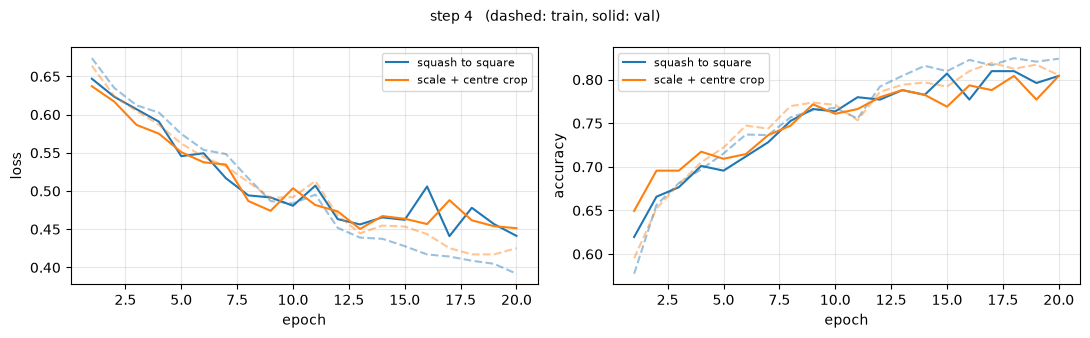

step             val acc  val loss  train acc  epoch       params  what changed            
01_simple_cnn     0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap     0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized     0.8098    0.4410     0.8240     17      241,090  input normalisation
04_keep_aspect    0.8043    0.4617     0.8050     18      241,090  scaling + cropping


In [16]:
step4 = experiment("04_keep_aspect", DeeperCNN, epochs=20, normalize=DATASET_STATS,
                   keep_aspect=True, note="scaling + cropping")
plot_histories([step3, step4], ["squash to square", "scale + centre crop"], "step 4")

results_table()

Cropping came out 1.9 points ahead of squashing (0.8098 against 0.7908). That looks like a
win, but two runs of the same code differ by about three points when nothing changes except
the order of the two class labels, so a difference this size is inside the noise and we
cannot claim the crop is better.

It is worth remembering what the crop costs: scaling the short side and taking the centre
throws away a quarter of the median image, and more than a third of every fifth one. If a
hotdog sits near the edge of a wide photo, it can be cropped out of a picture that is still
labelled as a hotdog.

The later steps keep the crop, but as an arbitrary choice between two options that measure
the same, not as an improvement.

## Step 5: augmentation

The training accuracy runs well ahead of validation, so the model is fitting details of
individual pictures. Horizontal flips, small rotations and mild colour jitter produce a new
variant of every image on every epoch, and none of them change what the picture shows.

More variety per epoch means slower convergence, so this run gets forty epochs.

  epoch  1/40  train 0.6675/0.5890   val 0.6165/0.6549
  epoch  2/40  train 0.6122/0.6637   val 0.5926/0.6821
  epoch  3/40  train 0.5981/0.6909   val 0.5727/0.6875
  epoch  4/40  train 0.5730/0.7045   val 0.5690/0.7038
  epoch  5/40  train 0.5780/0.7147   val 0.5679/0.7038
  epoch  6/40  train 0.5518/0.7269   val 0.5313/0.7092
  epoch  7/40  train 0.5320/0.7514   val 0.5161/0.7337
  epoch  8/40  train 0.5167/0.7677   val 0.5056/0.7310
  epoch  9/40  train 0.5051/0.7568   val 0.5477/0.7554
  epoch 10/40  train 0.5234/0.7568   val 0.5031/0.7636
  epoch 11/40  train 0.4960/0.7602   val 0.6211/0.7255
  epoch 12/40  train 0.5070/0.7643   val 0.4935/0.7853
  epoch 13/40  train 0.4843/0.7751   val 0.4762/0.8016
  epoch 14/40  train 0.4520/0.7935   val 0.5017/0.7962
  epoch 15/40  train 0.4516/0.7914   val 0.4334/0.8152
  epoch 16/40  train 0.4453/0.7921   val 0.4387/0.8071
  epoch 17/40  train 0.4400/0.8105   val 0.4437/0.8043
  epoch 18/40  train 0.4509/0.7969   val 0.4740/0.7799
  epoch 19

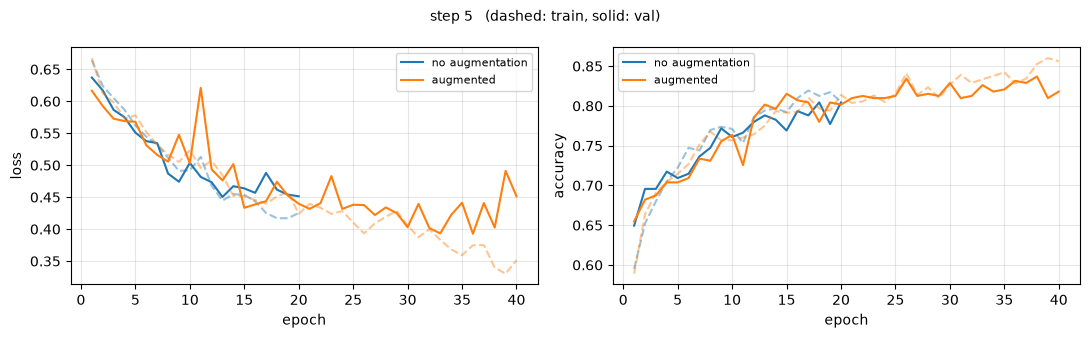

step             val acc  val loss  train acc  epoch       params  what changed            
01_simple_cnn     0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap     0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized     0.8098    0.4410     0.8240     17      241,090  input normalisation
04_keep_aspect    0.8043    0.4617     0.8050     18      241,090  scaling + cropping
05_augment        0.8370    0.4025     0.8560     38      241,090  + augmentation


In [17]:
step5 = experiment("05_augment", DeeperCNN, epochs=40, normalize=DATASET_STATS, 
                   keep_aspect=True, augment=True, note="+ augmentation")
plot_histories([step4, step5], ["no augmentation", "augmented"], "step 5")

results_table()

## Step 6: weight decay

Another tecnique to penalty large weights - is to apply weight decay. 
Applied separately from the gradient by AdamW rather than folded into the loss as plain Adam would. 
Large weights let the decision surface bend sharply around individual examples and penalties keep it smoother.

  epoch  1/40  train 0.6675/0.5897   val 0.6165/0.6549
  epoch  2/40  train 0.6122/0.6644   val 0.5926/0.6848
  epoch  3/40  train 0.5982/0.6902   val 0.5726/0.6821
  epoch  4/40  train 0.5732/0.7045   val 0.5695/0.7038
  epoch  5/40  train 0.5790/0.7113   val 0.5706/0.7038
  epoch  6/40  train 0.5530/0.7235   val 0.5344/0.7038
  epoch  7/40  train 0.5330/0.7452   val 0.5169/0.7310
  epoch  8/40  train 0.5214/0.7717   val 0.5087/0.7391
  epoch  9/40  train 0.5071/0.7418   val 0.5709/0.7391
  epoch 10/40  train 0.5260/0.7514   val 0.5123/0.7690
  epoch 11/40  train 0.4944/0.7568   val 0.6199/0.7283
  epoch 12/40  train 0.5063/0.7670   val 0.4968/0.7826
  epoch 13/40  train 0.4872/0.7806   val 0.4791/0.7908
  epoch 14/40  train 0.4530/0.7955   val 0.4911/0.7908
  epoch 15/40  train 0.4535/0.7921   val 0.4344/0.8152
  epoch 16/40  train 0.4487/0.7955   val 0.4318/0.8016
  epoch 17/40  train 0.4420/0.8084   val 0.4389/0.8071
  epoch 18/40  train 0.4582/0.7894   val 0.4747/0.7853
  epoch 19

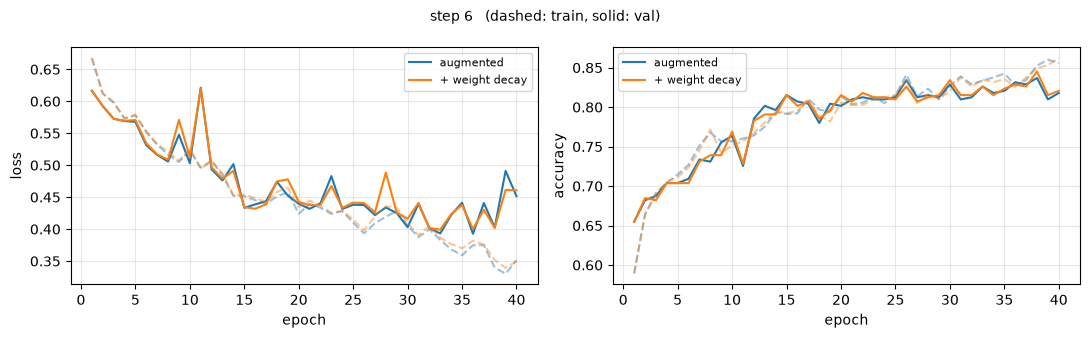

step              val acc  val loss  train acc  epoch       params  what changed            
01_simple_cnn      0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap      0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized      0.8098    0.4410     0.8240     17      241,090  input normalisation
04_keep_aspect     0.8043    0.4617     0.8050     18      241,090  scaling + cropping
05_augment         0.8370    0.4025     0.8560     38      241,090  + augmentation
06_weight_decay    0.8451    0.4019     0.8621     38      241,090  + weight decay


In [18]:
step6 = experiment("06_weight_decay", DeeperCNN, epochs=40, normalize=DATASET_STATS, augment=True, 
                   keep_aspect=True, optimizer_fn=lambda p: torch.optim.AdamW(p, lr=1e-3, weight_decay=1e-2), 
                   note="+ weight decay")
plot_histories([step5, step6], ["augmented", "+ weight decay"], "step 6")

results_table()

## Step 7: batch normalisation

Normalising the input helps the first layer and batch norm does the same for every layer,
rescaling activations to zero mean and unit variance inside the network with a learnable
scale and shift so the network can undo it where that helps.

Convolution bias is switched off in these blocks, because batch norm subtracts the mean
immediately afterwards and makes a constant bias redundant.

  epoch  1/40  train 0.6043/0.6800   val 0.6666/0.6250
  epoch  2/40  train 0.5254/0.7405   val 0.5404/0.7364
  epoch  3/40  train 0.5159/0.7520   val 0.5169/0.7690
  epoch  4/40  train 0.4937/0.7758   val 0.5342/0.7663
  epoch  5/40  train 0.4863/0.7697   val 0.4770/0.7609
  epoch  6/40  train 0.4601/0.7908   val 0.4633/0.7853
  epoch  7/40  train 0.4491/0.7969   val 0.4443/0.7853
  epoch  8/40  train 0.4537/0.7982   val 0.5651/0.7582
  epoch  9/40  train 0.4372/0.8003   val 0.4645/0.8071
  epoch 10/40  train 0.4355/0.8043   val 0.4389/0.8261
  epoch 11/40  train 0.4331/0.7955   val 0.4607/0.8016
  epoch 12/40  train 0.4165/0.8111   val 0.4295/0.8207
  epoch 13/40  train 0.4143/0.8247   val 0.4062/0.8098
  epoch 14/40  train 0.4321/0.8016   val 0.7304/0.7391
  epoch 15/40  train 0.4216/0.8132   val 0.4439/0.8098
  epoch 16/40  train 0.4295/0.7935   val 0.4830/0.7908
  epoch 17/40  train 0.4173/0.8071   val 0.4538/0.8098
  epoch 18/40  train 0.4095/0.8207   val 0.4769/0.8234
  epoch 19

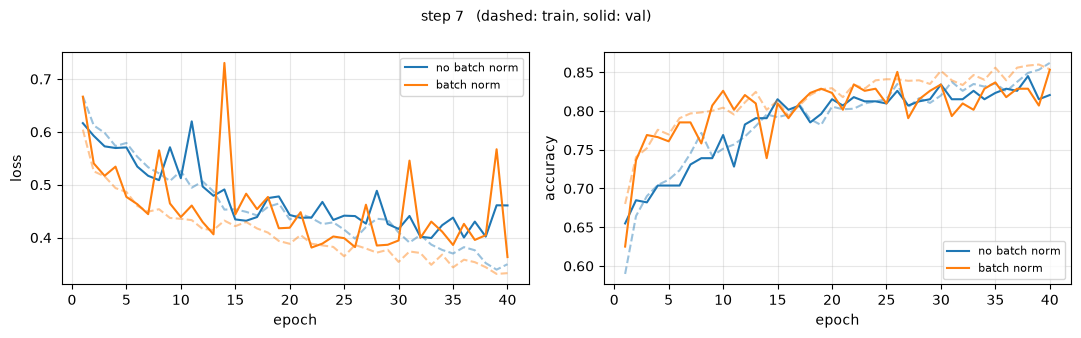

step              val acc  val loss  train acc  epoch       params  what changed            
01_simple_cnn      0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap      0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized      0.8098    0.4410     0.8240     17      241,090  input normalisation
04_keep_aspect     0.8043    0.4617     0.8050     18      241,090  scaling + cropping
05_augment         0.8370    0.4025     0.8560     38      241,090  + augmentation
06_weight_decay    0.8451    0.4019     0.8621     38      241,090  + weight decay
07_batchnorm       0.8533    0.3632     0.8539     40      241,442  + batch norm


In [19]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


step7 = experiment("07_batchnorm", BatchNormCNN, epochs=40, normalize=DATASET_STATS, augment=True, 
                   keep_aspect=True, optimizer_fn=lambda p: torch.optim.AdamW(p, lr=1e-3, weight_decay=1e-2), 
                   note="+ batch norm")
plot_histories([step6, step7], ["no batch norm", "batch norm"], "step 7")

results_table()

## Step 8: borrowing features from ImageNet

Everything so far learned its filters from 1472 pictures. A ResNet-18 trained on ImageNet
learned its from 1.2 million, and its early layers are not specific to ImageNet classes:
edges, colour boundaries and textures are the same in any photograph.

The backbone is frozen and only a two-class head is trained, which amounts to a logistic
regression on 512 precomputed features. Pretrained weights expect ImageNet channel
statistics, so those replace ours.

  epoch  1/10  train 0.5191/0.7330   val 0.3319/0.8560
  epoch  2/10  train 0.3560/0.8410   val 0.2955/0.8723
  epoch  3/10  train 0.3076/0.8777   val 0.2751/0.8777
  epoch  4/10  train 0.3019/0.8798   val 0.2641/0.8913
  epoch  5/10  train 0.2716/0.8899   val 0.2529/0.8886
  epoch  6/10  train 0.2685/0.8852   val 0.2490/0.8967
  epoch  7/10  train 0.2561/0.8927   val 0.2500/0.8913
  epoch  8/10  train 0.2812/0.8750   val 0.2510/0.8913
  epoch  9/10  train 0.2495/0.8961   val 0.2424/0.8940
  epoch 10/10  train 0.2460/0.8927   val 0.2414/0.8940
08_resnet18_frozen: best val acc 0.8967 (epoch 6), 74s


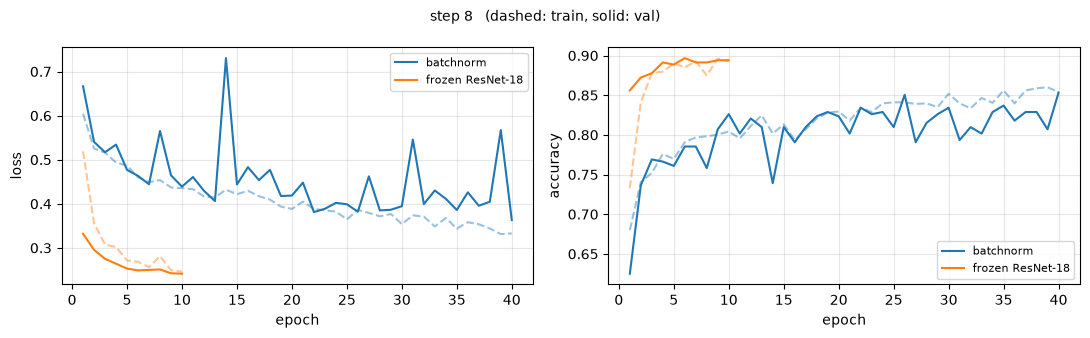

step                 val acc  val loss  train acc  epoch       params  what changed               
01_simple_cnn         0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap         0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized         0.8098    0.4410     0.8240     17      241,090  input normalisation
04_keep_aspect        0.8043    0.4617     0.8050     18      241,090  scaling + cropping
05_augment            0.8370    0.4025     0.8560     38      241,090  + augmentation
06_weight_decay       0.8451    0.4019     0.8621     38      241,090  + weight decay
07_batchnorm          0.8533    0.3632     0.8539     40      241,442  + batch norm
08_resnet18_frozen    0.8967    0.2490     0.8927      6   11,177,538  frozen ResNet-18 + new head


In [20]:
# the channel statistics ResNet was trained with; our own images are redder
# and more contrasty, but the pretrained weights expect these
IMAGENET_STATS = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


def resnet18_head_only():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


step8 = experiment("08_resnet18_frozen", resnet18_head_only, epochs=10, keep_aspect=True,
                   normalize=IMAGENET_STATS, augment=True, optimizer_fn=lambda p: torch.optim.AdamW(
                       [q for q in p if q.requires_grad], lr=1e-3, weight_decay=1e-2),
                   note="frozen ResNet-18 + new head")
plot_histories([step7, step8], ["batchnorm", "frozen ResNet-18"], "step 8")

results_table()

## Step 9: fine-tuning at native resolution

The whole network is unfrozen so the borrowed filters can adapt to food photographs, and
the input goes to 224x224, the resolution ResNet-18 was trained at.

Fine-tuning needs a much smaller learning rate than training from scratch: at 1e-3 the
first few batches would overwrite the pretrained weights before they were used.

  epoch  1/8  train 0.2565/0.8920   val 0.2623/0.9130
  epoch  2/8  train 0.1267/0.9484   val 0.1754/0.9348
  epoch  3/8  train 0.0690/0.9776   val 0.2590/0.9022
  epoch  4/8  train 0.0482/0.9844   val 0.1838/0.9348
  epoch  5/8  train 0.0224/0.9952   val 0.1851/0.9293
  epoch  6/8  train 0.0160/0.9966   val 0.2064/0.9239
  epoch  7/8  train 0.0146/0.9973   val 0.1968/0.9321
  epoch  8/8  train 0.0174/0.9966   val 0.1989/0.9321
09_resnet18_finetune_224: best val acc 0.9348 (epoch 2), 363s


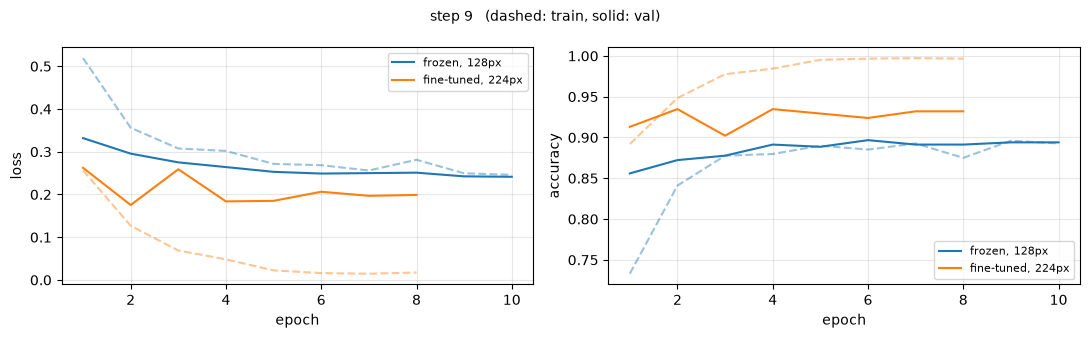

step                       val acc  val loss  train acc  epoch       params  what changed               
01_simple_cnn               0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap               0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized               0.8098    0.4410     0.8240     17      241,090  input normalisation
04_keep_aspect              0.8043    0.4617     0.8050     18      241,090  scaling + cropping
05_augment                  0.8370    0.4025     0.8560     38      241,090  + augmentation
06_weight_decay             0.8451    0.4019     0.8621     38      241,090  + weight decay
07_batchnorm                0.8533    0.3632     0.8539     40      241,442  + batch norm
08_resnet18_frozen          0.8967    0.2490     0.8927      6   11,177,538  frozen ResNet-18 + new head
09_resnet18_finetune_224    0.9348    0.1754     0.9966      2   11,177,538  fine-tuned, 224px


In [21]:
def resnet18_full():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


step9 = experiment("09_resnet18_finetune_224", resnet18_full, epochs=8, size=224,
                    batch_size=32, normalize=IMAGENET_STATS, augment=True, keep_aspect=True,
                    optimizer_fn=lambda p: torch.optim.AdamW(p, lr=1e-4, weight_decay=1e-2),
                    scheduler_fn=lambda o: torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=8),
                    note="fine-tuned, 224px")
plot_histories([step8, step9], ["frozen, 128px", "fine-tuned, 224px"], "step 9")

results_table()

## Step 10: a newer backbone

ResNet-18 is from 2015. ConvNeXt, from 2022, keeps the convolutional structure but adopts
ideas from vision transformers: 7x7 depthwise convolutions, inverted bottlenecks, layer
normalisation and GELU. Label smoothing replaces the hard 0/1 targets with 0.95/0.05, which
stops the network pushing logits towards infinity on the ambiguous pictures this dataset is
full of.

It is trained with a batch of 8 rather than 32: the activations of a 28-million-parameter
network at 224x224 do not fit in 8 GB alongside everything else the kernel is holding.

  epoch  1/5  train 0.3355/0.9205   val 0.2747/0.9592
  epoch  2/5  train 0.2411/0.9789   val 0.2867/0.9375
  epoch  3/5  train 0.2156/0.9946   val 0.2502/0.9701
  epoch  4/5  train 0.2071/0.9973   val 0.2416/0.9783
  epoch  5/5  train 0.2042/0.9993   val 0.2425/0.9701
10_convnext_tiny_224: best val acc 0.9783 (epoch 4), 793s


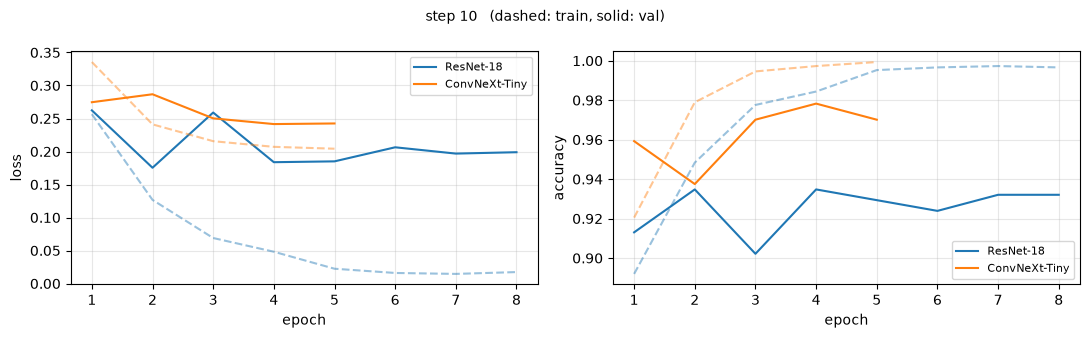

step                       val acc  val loss  train acc  epoch       params  what changed                  
01_simple_cnn               0.8016    0.4408     0.8668      8    2,121,122  starting point
02_deeper_gap               0.7962    0.4815     0.7826     20      241,090  deeper + global avg pool
03_normalized               0.8098    0.4410     0.8240     17      241,090  input normalisation
04_keep_aspect              0.8043    0.4617     0.8050     18      241,090  scaling + cropping
05_augment                  0.8370    0.4025     0.8560     38      241,090  + augmentation
06_weight_decay             0.8451    0.4019     0.8621     38      241,090  + weight decay
07_batchnorm                0.8533    0.3632     0.8539     40      241,442  + batch norm
08_resnet18_frozen          0.8967    0.2490     0.8927      6   11,177,538  frozen ResNet-18 + new head
09_resnet18_finetune_224    0.9348    0.1754     0.9966      2   11,177,538  fine-tuned, 224px
10_convnext_tiny_224        0.9

In [22]:
def convnext_tiny():
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    model.classifier[2] = nn.Sequential(nn.Dropout(0.3),
                                        nn.Linear(model.classifier[2].in_features, 2))
    return model


# batch 8: at 32 the activations do not fit in 8 GB
step10 = experiment("10_convnext_tiny_224", convnext_tiny, epochs=5, size=224, batch_size=8,
                    normalize=IMAGENET_STATS, augment=True, keep_aspect=True,
                    loss_fn=nn.CrossEntropyLoss(label_smoothing=0.1),
                    optimizer_fn=lambda p: torch.optim.AdamW(p, lr=1e-4, weight_decay=1e-2),
                    scheduler_fn=lambda o: torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=5),
                    note="ConvNeXt-Tiny, label smoothing")
plot_histories([step9, step10], ["ResNet-18", "ConvNeXt-Tiny"], "step 10")

results_table()

## The test set

Every number so far came from validation. The model that scored best there is now run on
the test folder.

The first accuracy is over all 1862 test images, which is what the assignment asks for. 
The second leaves out the images that also sit in our training set.

In [26]:
@torch.no_grad()
def predict(model, loader):
    """Class probabilities and true labels for a whole loader."""
    model.eval()
    probs, targets = [], []
    for images, labels in loader:
        probs.append(F.softmax(model(images.to(device)), dim=1).cpu())
        targets.append(labels)
    return torch.cat(probs), torch.cat(targets)


_, _, test_loader = make_loaders(*build_transforms(size=224, normalize=IMAGENET_STATS,
                                                   keep_aspect=True), batch_size=32)
test_probs, test_targets = predict(step10["model"], test_loader)
predicted = test_probs.argmax(1)

correct = predicted == test_targets
unseen = torch.from_numpy(TEST_UNSEEN)

print(f"test accuracy, all {len(test_targets)} images: {correct.float().mean():.4f}")
print(f"test accuracy, {int(unseen.sum())} never-seen images: {correct[unseen].float().mean():.4f}")


ConvNeXt-Tiny, best val acc 0.9783

test accuracy, all 1862 images: 0.9742
test accuracy, 1831 never-seen images: 0.9738


In [27]:
# confusion matrix
matrix = np.zeros((2, 2), dtype=int)
for t, p in zip(test_targets.tolist(), predicted.tolist()):
    matrix[t, p] += 1

print(f"\n{'':>14}{'predicted not hotdog':>22}{'predicted hotdog':>18}")
for i, name in enumerate(CLASS_NAMES):
    print(f"true {name:>9}{matrix[i, 0]:>22}{matrix[i, 1]:>18}")

tp, fp, fn = matrix[1, 1], matrix[0, 1], matrix[1, 0]
print(f"\nprecision {tp / (tp + fp):.4f}")
print(f"recall {tp / (tp + fn):.4f}")
print(f"errors {int(matrix.sum() - matrix.trace())} of {matrix.sum()}")


                predicted not hotdog  predicted hotdog
true not hotdog                   948                19
true    hotdog                    29               866

precision 0.9785
recall 0.9676
errors 48 of 1862


## Saliency maps

A saliency map shows which pixels the hotdog score is most sensitive to: 
the gradient of that score with respect to the input image.

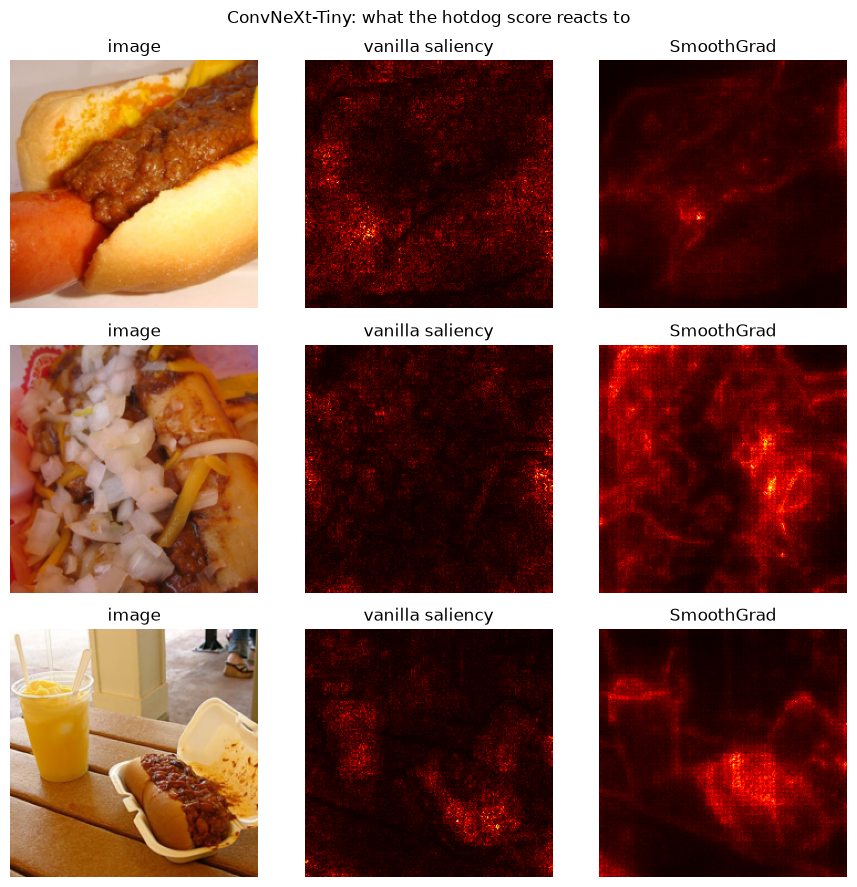

In [ ]:
def denormalize(image, stats=IMAGENET_STATS):
    """Normalised tensor back to a displayable [0, 1] RGB array"""
    mean, std = (torch.tensor(s).view(3, 1, 1) for s in stats)

    return (image * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def input_gradient(model, image, target=1):
    """Gradient of the target class score with respect to the input pixels"""
    image = image.clone().unsqueeze(0).to(device).requires_grad_()
    model.zero_grad()
    model(image)[0, target].backward()

    return image.grad.detach()


def vanilla_saliency(model, image, target=1):
    # strongest absolute gradient over the three colour channels
    return input_gradient(model, image, target).abs().amax(dim=1)[0].cpu().numpy()


def smoothgrad(model, image, target=1, n_samples=30, spread=0.15):
    # every noisy copy is a sample from N(image, sigma^2 I)
    sigma = spread * (image.max() - image.min()).item()
    total = torch.zeros(1, *image.shape, device=device)
    for _ in range(n_samples):
        total += input_gradient(model, image + sigma * torch.randn_like(image), target).abs()
        
    return (total / n_samples).amax(dim=1)[0].cpu().numpy()


set_seed()
model = step10["model"].eval()
test_set = test_loader.dataset

# the first three test hotdogs the model gets right
hotdog_idx = torch.nonzero((test_targets == 1) & correct).flatten()[:3].tolist()

fig, axes = plt.subplots(len(hotdog_idx), 3, figsize=(9, 3 * len(hotdog_idx)))
for row, idx in zip(axes, hotdog_idx):
    image, _ = test_set[idx]
    maps = [denormalize(image), vanilla_saliency(model, image), smoothgrad(model, image)]
    for ax, shown, title in zip(row, maps, ["image", "vanilla saliency", "SmoothGrad"]):
        ax.imshow(shown, cmap=None if shown.ndim == 3 else "hot")
        ax.set_title(title)
        ax.axis("off")
fig.suptitle("ConvNeXt-Tiny: what the hotdog score reacts to")
fig.tight_layout()
plt.show()